In [94]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [47]:
df=pd.read_csv("../data/processed/order_level_dataset.csv")

In [48]:
df.head()

,order_id,customer_id,order_purchase_timestamp,order_approved_at,order_estimated_delivery_date,late_delivery,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,...,total_freight_value,average_product_weight_g,average_product_length_cm,average_product_height_cm,average_product_width_cm,number_of_product_categories,total_payment_installments,total_payment_value,number_of_payment_records,primary_payment_type
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-18,0,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,...,8.72,500.0,19.0,8.0,13.0,1,3.0,38.71,3.0,voucher
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-08-13,0,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,...,22.76,400.0,19.0,13.0,19.0,1,1.0,141.46,1.0,boleto
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-09-04,0,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,...,19.22,420.0,24.0,19.0,21.0,1,3.0,179.12,1.0,credit_card
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-12-15,0,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,...,27.20,450.0,30.0,10.0,20.0,1,1.0,72.20,1.0,credit_card
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-26,0,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,...,8.72,250.0,51.0,15.0,15.0,1,1.0,28.62,1.0,credit_card


In [49]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 96456 entries, 0 to 96455
Data columns (total 24 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   order_id                       96456 non-null  str    
 1   customer_id                    96456 non-null  str    
 2   order_purchase_timestamp       96456 non-null  str    
 3   order_approved_at              96456 non-null  str    
 4   order_estimated_delivery_date  96456 non-null  str    
 5   late_delivery                  96456 non-null  int64  
 6   customer_unique_id             96456 non-null  str    
 7   customer_zip_code_prefix       96456 non-null  int64  
 8   customer_city                  96456 non-null  str    
 9   customer_state                 96456 non-null  str    
 10  number_of_items                96456 non-null  int64  
 11  number_of_unique_products      96456 non-null  int64  
 12  number_of_unique_sellers       96456 non-null  int64  
 1

In [50]:
df['order_estimated_delivery_date']=pd.to_datetime(df['order_estimated_delivery_date'])

In [82]:
df[["order_purchase_timestamp", "order_approved_at"]] = (
    df[["order_purchase_timestamp", "order_approved_at"]]
    .apply(pd.to_datetime)
)

In [83]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 96456 entries, 0 to 96455
Data columns (total 24 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       96456 non-null  str           
 1   customer_id                    96456 non-null  str           
 2   order_purchase_timestamp       96456 non-null  datetime64[us]
 3   order_approved_at              96456 non-null  datetime64[us]
 4   order_estimated_delivery_date  96456 non-null  datetime64[us]
 5   late_delivery                  96456 non-null  int64         
 6   customer_unique_id             96456 non-null  str           
 7   customer_zip_code_prefix       96456 non-null  int64         
 8   customer_city                  96456 non-null  str           
 9   customer_state                 96456 non-null  str           
 10  number_of_items                96456 non-null  int64         
 11  number_of_unique_products 

In [52]:
df.duplicated().sum()

np.int64(0)

In [53]:
df['late_delivery'].value_counts()

late_delivery
0    88630
1     7826
Name: count, dtype: int64

In [54]:
df.shape

(96456, 24)

In [55]:
target_summary = (
    df["late_delivery"]
    .value_counts()
    .sort_index()
    .rename_axis("late_delivery")
    .reset_index(name="order_count")
)

target_summary["delivery_outcome"] = target_summary[
    "late_delivery"
].map({
    0: "On time",
    1: "Late"
})

target_summary["percentage"] = (
    target_summary["order_count"]
    / target_summary["order_count"].sum()
    * 100
).round(2)

target_summary[
    ["delivery_outcome", "order_count", "percentage"]
]

,delivery_outcome,order_count,percentage
0,On time,88630,91.89
1,Late,7826,8.11


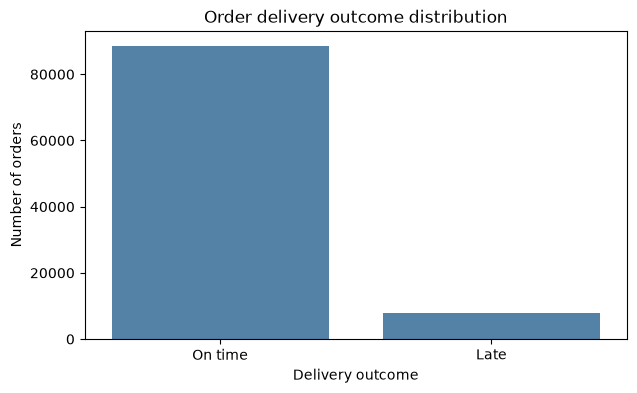

In [56]:
plot_data = df.copy()

plot_data["delivery_outcome"] = plot_data["late_delivery"].map({
    0: "On time",
    1: "Late"
})

plt.figure(figsize=(7, 4))

sns.countplot(
    data=plot_data,
    x="delivery_outcome",
    order=["On time", "Late"],
    color="steelblue"
)

plt.title("Order delivery outcome distribution")
plt.xlabel("Delivery outcome")
plt.ylabel("Number of orders")
plt.show()

In [57]:
always_on_time_accuracy = (
    (df["late_delivery"] == 0).mean() * 100
)

print(
    f"If a model predicts every order as on time, "
    f"its accuracy is {always_on_time_accuracy:.2f}%."
)

If a model predicts every order as on time, its accuracy is 91.89%.


In [58]:
numeric_cols = [
    "number_of_items",
    "total_product_price",
    "total_freight_value",
    "average_product_weight_g",
    "total_payment_value",
    "total_payment_installments",
    "number_of_payment_records"
]
df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
number_of_items,96456.0,1.142220,0.538854,1.00,1.00,1.00,1.00,21.00
total_product_price,96456.0,137.042574,209.064238,0.85,45.90,86.50,149.90,13440.00
total_freight_value,96456.0,22.786159,21.561315,0.00,13.85,17.17,24.02,1794.96
average_product_weight_g,96440.0,2098.157715,3744.777705,0.00,300.00,700.00,1800.00,40425.00
total_payment_value,96455.0,159.858258,218.833168,9.59,61.88,105.28,176.33,13664.08
total_payment_installments,96455.0,2.978415,2.738049,0.00,1.00,2.00,4.00,26.00
number_of_payment_records,96455.0,1.044363,0.369644,1.00,1.00,1.00,1.00,26.00


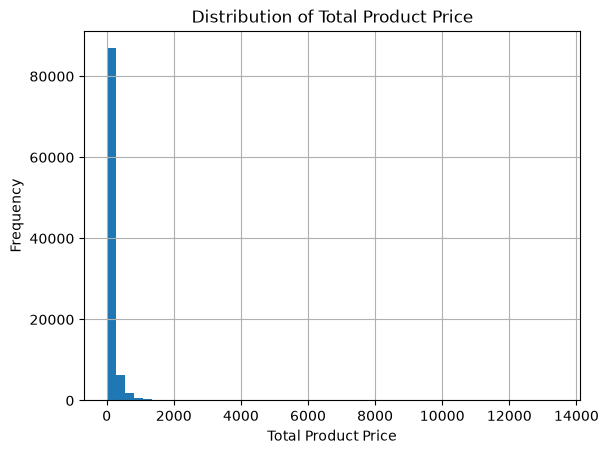

In [59]:
df["total_product_price"].hist(bins=50)

plt.xlabel("Total Product Price")
plt.ylabel("Frequency")
plt.title("Distribution of Total Product Price")
plt.show()

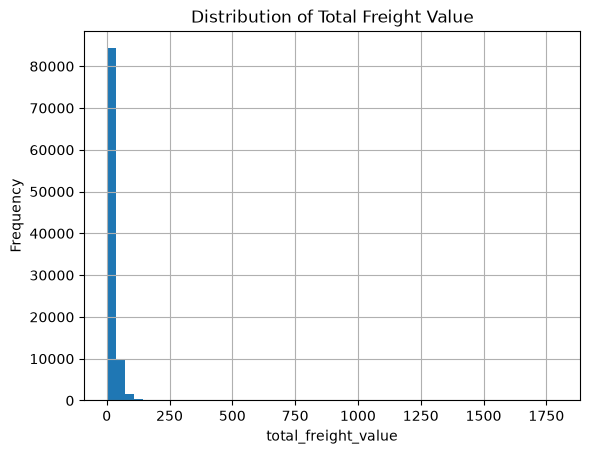

In [60]:
df["total_freight_value"].hist(bins=50)

plt.xlabel("total_freight_value")
plt.ylabel("Frequency")
plt.title("Distribution of Total Freight Value")
plt.show()

In [61]:
print(df["total_product_price"].skew())
print(df["total_freight_value"].skew())

9.885131215259673
12.27631719961641


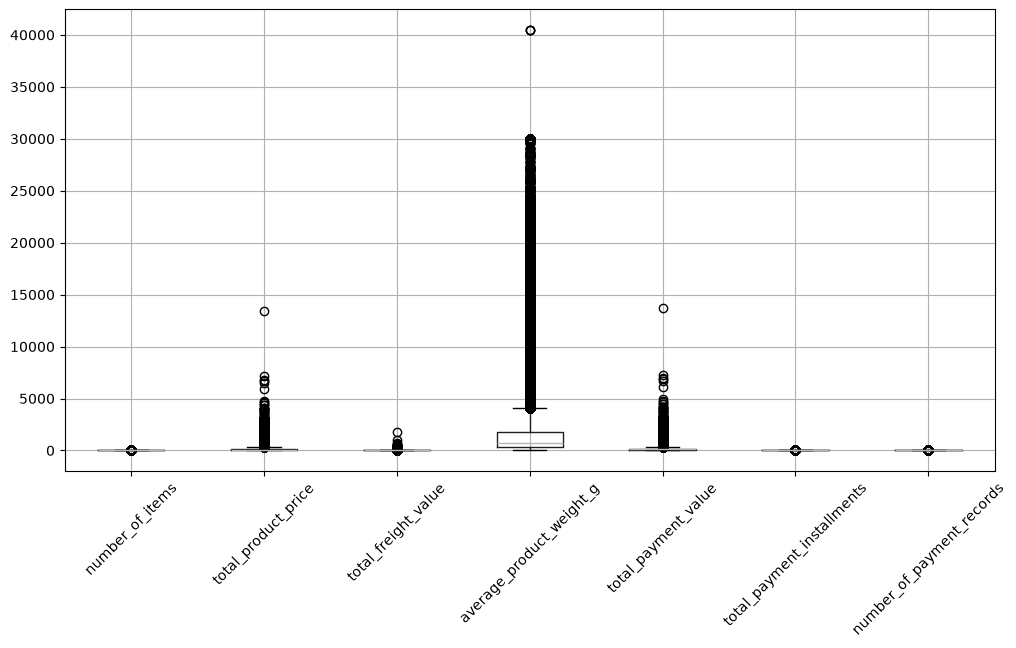

In [62]:
df[numeric_cols].boxplot(figsize=(12, 6))
plt.xticks(rotation=45)
plt.show()

In [63]:
(df["total_freight_value"] == 0).sum()

np.int64(336)

In [64]:
df["number_of_items"].value_counts().sort_index()

number_of_items
1     86822
2      7391
3      1306
4       495
5       193
6       191
7        22
8         8
9         3
10        8
11        4
12        5
13        1
14        2
15        2
20        2
21        1
Name: count, dtype: int64

In [65]:
numeric_cols = [
    "number_of_items",
    "total_product_price",
    "total_freight_value",
    "average_product_weight_g",
    "total_payment_value",
    "total_payment_installments",
    "number_of_payment_records"
]

df.groupby("late_delivery")[numeric_cols].agg(
    ["mean", "median"]
)

number_of_items        total_product_price         \
                         mean median                mean median   
late_delivery                                                     
0                    1.144759    1.0          136.067449   85.5   
1                    1.113468    1.0          148.085933   89.9   

              total_freight_value         average_product_weight_g         \
                             mean  median                     mean median   
late_delivery                                                               
0                       22.623912  17.070              2071.727136  688.0   
1                       24.623620  18.055              2397.431850  750.0   

              total_payment_value         total_payment_installments         \
                             mean  median                       mean median   
late_delivery                                                                 
0                      158.721443  104.62                   2.971590    2.0   
1                      172.734414  112.27                   3.055719    2.0   

              number_of_payment_records         
                                   mean median  
late_delivery                                   
0                              1.044895    1.0  
1                              1.038339    1.0

In [66]:
df.groupby("late_delivery")["number_of_unique_sellers"].agg(
    ["mean", "median"]
)

,mean,median
late_delivery,,
0,1.014927,1.0
1,1.002300,1.0


In [67]:
df.columns

Index(['order_id', 'customer_id', 'order_purchase_timestamp',
       'order_approved_at', 'order_estimated_delivery_date', 'late_delivery',
       'customer_unique_id', 'customer_zip_code_prefix', 'customer_city',
       'customer_state', 'number_of_items', 'number_of_unique_products',
       'number_of_unique_sellers', 'total_product_price',
       'total_freight_value', 'average_product_weight_g',
       'average_product_length_cm', 'average_product_height_cm',
       'average_product_width_cm', 'number_of_product_categories',
       'total_payment_installments', 'total_payment_value',
       'number_of_payment_records', 'primary_payment_type'],
      dtype='str')

In [72]:
state_late_rate = (
    df
    .groupby("customer_state")
    .agg(
        total_orders=("order_id", "size"),
        late_orders=("late_delivery", "sum"),
        late_delivery_rate=("late_delivery", "mean")
    )
    .reset_index()
)

state_late_rate["late_delivery_rate"] = (
    state_late_rate["late_delivery_rate"] * 100
).round(2)

state_late_rate = state_late_rate.sort_values(
    "late_delivery_rate",
    ascending=False
)

state_late_rate

,customer_state,total_orders,late_orders,late_delivery_rate
1,AL,397,95,23.93
9,MA,716,141,19.69
16,PI,476,76,15.97
5,CE,1278,196,15.34
24,SE,335,51,15.22
4,BA,3256,457,14.04
18,RJ,12348,1664,13.48
26,TO,274,35,12.77
13,PA,946,117,12.37
7,ES,1995,244,12.23


In [73]:
reliable_state_late_rate = state_late_rate[
    state_late_rate["total_orders"] >= 100
]

reliable_state_late_rate

,customer_state,total_orders,late_orders,late_delivery_rate
1,AL,397,95,23.93
9,MA,716,141,19.69
16,PI,476,76,15.97
5,CE,1278,196,15.34
24,SE,335,51,15.22
4,BA,3256,457,14.04
18,RJ,12348,1664,13.48
26,TO,274,35,12.77
13,PA,946,117,12.37
7,ES,1995,244,12.23


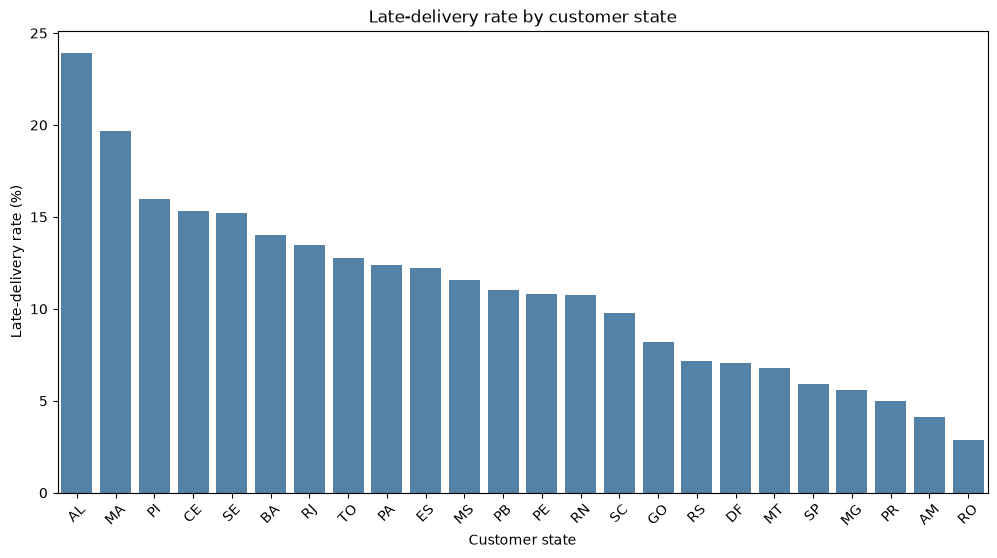

In [74]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=reliable_state_late_rate,
    x="customer_state",
    y="late_delivery_rate",
    color="steelblue"
)

plt.title("Late-delivery rate by customer state")
plt.xlabel("Customer state")
plt.ylabel("Late-delivery rate (%)")
plt.xticks(rotation=45)
plt.show()

In [84]:
df["purchase_year"] = (
    df["order_purchase_timestamp"].dt.year
)

df["purchase_month"] = (
    df["order_purchase_timestamp"].dt.month
)

df["purchase_day_of_week"] = (
    df["order_purchase_timestamp"].dt.dayofweek
)

df["purchase_hour"] = (
    df["order_purchase_timestamp"].dt.hour
)

df["approval_delay_hours"] = (
    (
        df["order_approved_at"]
        - df["order_purchase_timestamp"]
    )
    .dt.total_seconds()
    / 3600
)

df["estimated_delivery_days"] = (
    (
        df["order_estimated_delivery_date"]
        - df["order_approved_at"]
    )
    .dt.total_seconds()
    / 86400
)

In [93]:
invalid_estimated_mask = (
    df["estimated_delivery_days"] < 0
)

df.loc[
    invalid_estimated_mask,
    [
        "order_id",
        "order_approved_at",
        "order_estimated_delivery_date",
        "estimated_delivery_days"
    ]
]

,order_id,order_approved_at,order_estimated_delivery_date,estimated_delivery_days
42118,5e981569f5835c96e4b288363b3b8f63,2018-08-02 13:43:13,2018-08-02,-0.571678
49111,e73fe43cdcd166f7f0c6e3c2bf11a917,2018-08-20 15:57:28,2018-08-16,-4.664907
53698,9675440ebf61a1a3482cc6308e3ebd28,2018-08-24 22:05:08,2018-08-23,-1.920231
55914,394d17c2b71a726e205caaeee3d2aa3d,2018-08-08 23:31:22,2018-08-08,-0.980116
59704,6dcf0aeb8b1eb4021c26e1d0e9394979,2018-08-20 15:59:18,2018-08-15,-5.666181
89050,4387477eec4b3c89b39f3f454940d059,2018-08-20 15:56:29,2018-08-14,-6.664225


In [95]:
df["estimated_delivery_days_invalid"] = (
    invalid_estimated_mask.astype(int)
)

df.loc[
    invalid_estimated_mask,
    "estimated_delivery_days"
] = np.nan

In [97]:
(df["number_of_items"] == 0).sum()

np.int64(0)

In [98]:
(
    (
        df["total_product_price"]
        + df["total_freight_value"]
    ) == 0
).sum()

np.int64(0)

In [99]:
df["total_order_cost"]= df["total_product_price"] + df["total_freight_value"]

In [100]:
df["freight_ratio"]= df["total_freight_value"] / df["total_order_cost"]

In [101]:
df["average_item_price"] = df["total_product_price"] / df["number_of_items"]

In [103]:
df["average_product_volume_cm3"] = (
    df["average_product_length_cm"]
    * df["average_product_height_cm"]
    * df["average_product_width_cm"]
)

In [105]:
df.shape

(96456, 35)

In [106]:
product_dimension_columns = [
    "average_product_weight_g",
    "average_product_length_cm",
    "average_product_height_cm",
    "average_product_width_cm"
]

df["product_dimensions_missing"] = (
    df[product_dimension_columns]
    .isna()
    .any(axis=1)
    .astype(int)
)

In [107]:
df["product_dimensions_missing"]

0        0
1        0
2        0
3        0
4        0
        ..
96451    0
96452    0
96453    0
96454    0
96455    0
Name: product_dimensions_missing, Length: 96456, dtype: int64

In [110]:
df[
    ["product_dimensions_missing", "payment_information_missing"]
].value_counts()

product_dimensions_missing  payment_information_missing
0                           0                              96439
1                           0                                 16
0                           1                                  1
Name: count, dtype: int64

In [111]:
candidate_features = [
    "customer_state",
    "primary_payment_type",
    "number_of_items",
    "number_of_unique_products",
    "number_of_unique_sellers",
    "total_product_price",
    "total_freight_value",
    "average_product_weight_g",
    "average_product_length_cm",
    "average_product_height_cm",
    "average_product_width_cm",
    "number_of_product_categories",
    "total_payment_installments",
    "total_payment_value",
    "number_of_payment_records",
    "purchase_month",
    "purchase_day_of_week",
    "purchase_hour",
    "approval_delay_hours",
    "estimated_delivery_days",
    "total_order_cost",
    "freight_ratio",
    "average_item_price",
    "average_product_volume_cm3",
    "product_dimensions_missing",
    "payment_information_missing"
]

target_column = "late_delivery"

excluded_from_model = [
    "order_id",
    "customer_id",
    "customer_unique_id",
    "customer_city",
    "customer_zip_code_prefix",
    "late_delivery"
]

In [112]:
[column for column in candidate_features if column not in df.columns]

[]

In [113]:
new_numeric_features = [
    "approval_delay_hours",
    "estimated_delivery_days",
    "total_order_cost",
    "freight_ratio",
    "average_item_price",
    "average_product_volume_cm3"
]

np.isinf(
    df[new_numeric_features]
).sum()

approval_delay_hours          0
estimated_delivery_days       0
total_order_cost              0
freight_ratio                 0
average_item_price            0
average_product_volume_cm3    0
dtype: int64

In [114]:
df["order_id"].duplicated().sum()

np.int64(0)

In [116]:
leakage_columns = [
    "order_status",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "review_score",
    "review_comment_message"
]

[column for column in leakage_columns if column in df.columns]

[]

In [117]:
df.to_csv(
    "../data/processed/order_level_features.csv",
    index=False
)

In [119]:
df.columns

Index(['order_id', 'customer_id', 'order_purchase_timestamp',
       'order_approved_at', 'order_estimated_delivery_date', 'late_delivery',
       'customer_unique_id', 'customer_zip_code_prefix', 'customer_city',
       'customer_state', 'number_of_items', 'number_of_unique_products',
       'number_of_unique_sellers', 'total_product_price',
       'total_freight_value', 'average_product_weight_g',
       'average_product_length_cm', 'average_product_height_cm',
       'average_product_width_cm', 'number_of_product_categories',
       'total_payment_installments', 'total_payment_value',
       'number_of_payment_records', 'primary_payment_type', 'purchase_year',
       'purchase_month', 'purchase_day_of_week', 'purchase_hour',
       'approval_delay_hours', 'estimated_delivery_days',
       'estimated_delivery_days_invalid', 'total_order_cost', 'freight_ratio',
       'average_item_price', 'average_product_volume_cm3',
       'product_dimensions_missing', 'payment_information_missing'